In [ ]:
import subprocess

try:
    print("Updating package lists...")
    subprocess.run(["sudo", "apt-get", "update"], check=True, capture_output=True, text=True)
    print("Installing libxcomposite1, libatk1.0-0, libcairo2, libgdk-pixbuf2.0-0, and libgtk-3-0...")
    subprocess.run(["sudo", "apt-get", "install", "-y", "libxcomposite1", "libatk1.0-0", "libcairo2", "libgdk-pixbuf2.0-0", "libgtk-3-0"], check=True, capture_output=True, text=True)
    print("Required libraries installed successfully.")
except subprocess.CalledProcessError as e:
    print(f"Error installing libraries: {e.stderr}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [ ]:
!pip install shot-scraper
!shot-scraper install

In [ ]:
# %pip install tiktoken
%pip install nltk

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from wordcloud import WordCloud

import json
import re
import string
import html

In [6]:
from collections import Counter
# import tiktoken
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# Prepare parsing

In [7]:
def unify_content(content):
  combined_text = ""
  for key in content:
      combined_text += content[key]
  return combined_text


In [8]:
def clean(text):
  # remove all image content and text
  text = re.sub(r'<figure>.*?</figure>', '', text, flags=re.S)
  text = re.sub(r'<img>.*?</img>', '', text, flags=re.S)
  # remove wiki template syntax like {{{ARTIKEL-FLAGGE}}}
  text = re.sub(r'\{\{\{.*?\}\}\}', '', text, flags=re.S)
  # remove html entities (&nbsp; ...)
  text = html.unescape(text)
  #remove html tags
  plain_text = re.sub(r'<[^>]+>', ' ', text)
  # convert to lower case
  normalized_text = plain_text.lower()
  # Remove punctuation
  normalized_text = re.sub(f'[{re.escape(string.punctuation)}]', ' ', normalized_text)
  # Remove numbers
  normalized_text = re.sub(r'\d+', '', normalized_text)
  # Replace multiple spaces with a single space and remove leading/trailing whitespace
  normalized_text = re.sub(r'\s+', ' ', normalized_text).strip()
  # check for any special characters left in the text
  existing_no_word_chars = set(re.findall(r"[\W]", normalized_text))
  if len(existing_no_word_chars) > 0:
    for char in existing_no_word_chars:
      normalized_text = re.sub(char.strip(), '', normalized_text)

  return normalized_text

In [9]:
def get_clean_text(content):
  # clean_text = clean(unify_content(content))
  # #find remain characters that are neither words nor spaces
  # existing_no_word_chars = set(re.findall(r"[\W]", clean_text))
  # if len(existing_no_word_chars) > 0:
  #   for char in existing_no_word_chars:
  #     clean_text = re.sub(char.strip(), '', clean_text)
  return clean(unify_content(content))


In [10]:
def get_processed_article_data(target_url):
    # Run shot-scraper to get the content
    # The command needs to be properly escaped if running directly in shell
    # For subprocess.run, it's better to pass as a list
    cmd = ["shot-scraper", "javascript", "-i", "get_pdf.js", target_url]

    # Use capture_output=True to get stdout and stderr
    # text=True decodes stdout/stderr as text
    # check=True raises an exception for non-zero exit codes
    process = subprocess.run(cmd, capture_output=True, text=True, check=True)

    # Parse the JSON output from shot-scraper
    data = json.loads(process.stdout)

    # Parse HTML nodes into parsed_content
    parsed_content = {}
    for node_title in data['order']:
        parsed_content[node_title] = ''.join(data['obj'][node_title])

    # Get clean text
    clean_text = get_clean_text(parsed_content)

    return data, parsed_content, clean_text

In [11]:
def create_html_page(data, parsed_content):
  page = ''
  for indx, node in enumerate(data['order']):
    segment = f"""<{data['tags'][indx].lower()}> {node.replace('_', ' ')}</{data['tags'][indx].lower()}>
    {parsed_content[node]}
    """
    page += segment
  return page

In [12]:
def run_process(target_url):
  data, parsed_content, clean_text = get_processed_article_data(target_url)
  def result(key):
    match key:
      case 'data':
        return data
      case 'parsed_content':
        return parsed_content
      case 'clean_text':
        return clean_text
  return result



# Scrape Page Content

In [13]:
############################### Trial for Testing ##############################

# !shot-scraper javascript https://en.wikipedia.org/wiki/MapReduce '(() => { function tableToObjects() {const nodes = Array.from(document.querySelectorAll("section:first-child table, section:first-child p, .mw-heading ~ p, .mw-heading ~ ul, .mw-heading ~ table, ol.references, h1, h2, h3, h4")); const obj = {}; let content = []; let title = ""; const order = []; const tags = []; for (let i = 0; i < nodes.length; i++) { const node = nodes[i]; if (node.id && ["H1", "H2", "H3", "H4"].includes(node.tagName)) {content = [];  title = node.innerText; order.push(title); tags.push(node.tagName?.toLowerCase())} else {content.push(`<${node.tagName.toLowerCase()}>${node.getHTML()}</${node.tagName.toLowerCase()}>`)};  obj[title] = content } return ({obj, order, tags});} return tableToObjects();})'

In [14]:
get_pdf_script = """
(() => { function tableToObjects() {const nodes = Array.from(document.querySelectorAll("section:first-child table, section:first-child p, .mw-heading ~ p, .mw-heading ~ ul, .mw-heading ~ table, ol.references, h1, h2, h3, h4")); const obj = {}; let content = []; let title = ""; const order = []; const tags = []; for (let i = 0; i < nodes.length; i++) { const node = nodes[i]; if (node.id && ["H1", "H2", "H3", "H4"].includes(node.tagName)) {content = [];  title = node.innerText; order.push(title); tags.push(node.tagName?.toLowerCase())} else {content.push(`<${node.tagName.toLowerCase()}>${node.getHTML()}</${node.tagName.toLowerCase()}>`)};  obj[title] = content } return ({obj, order, tags});} return tableToObjects();})
"""
if not Path('get_pdf.js').exists():
  with open('get_pdf.js', 'w') as f:
      f.write(get_pdf_script)

## User Input and Scraping

In [15]:
input_url = input('paste the url of a wikipedia page')
url = input_url if input_url else 'https://als.wikipedia.org/wiki/Schweiz'

# Call the new function to get processed data
#data, parsed_content, clean_text = get_processed_article_data(url)
process = run_process(url)

paste the url of a wikipedia page


### Display the Html

In [ ]:
from IPython.display import HTML, display
display(HTML(create_html_page(process('data'), process('parsed_content'))))

#### Break down the structure of the page and store it in pandas

In [17]:
#parsed_content

# Analyze content
Perform word frequency analysis on the the scraped content of the Wikipedia article. The analysis should include cleaning and normalizing the text, tokenizing words, removing stop words, identifying the top N most frequent words, visualizing these words with a bar chart, and summarizing the insights to highlight the article's main themes.

In [18]:
path = Path('language_map.json')
if not path.exists():
  with open('language_map.json', 'w') as f:
    json.dump({
    "als": "german",
    "el": "german",
    "en": "english",
    "es": "spanish",
    "fr": "french",
    "it": "italian",
    "de": "german",
    "nl": "dutch",
    "pl": "polish",
    "pt": "portuguese",
    "ru": "russian",
    "sv": "swedish",
    "tr": "turkish",
    "zh": "chinese",
    "zh-tw": "chinese",
    "zh-cn": "chinese",
    "zh-sg": "chinese",
    "hu": "hungarian",
    "ro": "romanian",
    "nl-be": "dutch",
    "nl-nl": "dutch",
    "da": "danish",
    "fi": "finnish",
    "no": "norwegian",
    "cs": "czech",
    "sk": "slovak",
    "sl": "slovenian",
    "hr": "croatian",
    "bg": "bulgarian",
    "albanian": "albanian",
    "ar": "arabic",
    "az": "azerbaijani",
    "be": "belarusian",
    "ca": "catalan"
}, f)

## Tokenize and Count Words


Split the cleaned text into individual words (tokens) and then calculate the frequency of each word. This will give us a raw count of how often each word appears in the Wikipedia article.


In [19]:
# import nltk
# from nltk.tokenize import word_tokenize
# tokenizer = tiktoken.get_encoding("gpt2")
def get_word_counts(text):
  tokens = text.split()
  word_counts = Counter(tokens)
  return word_counts;


## Remove Stop Words

Filter out common English (or appropriate language for the article) stop words (e.g., 'the', 'is', 'and') from the word frequency counts, as these often do not carry significant meaning for analysis.


In [20]:
# check available languages for stopwords
#stopwords.fileids()

In [21]:
def get_stopwords_for_content(target_url, language = 'english'):
  with open('language_map.json', 'r') as f:
    language_map = json.load(f)
  try:
    lang = target_url.split('//')[-1].split('.')[0]
    stopwords_flag = language_map.get(lang) or language
    stopwords_for_content = set(stopwords.words(stopwords_flag))
  except LookupError:
    stopwords_for_content = set(stopwords.words(language))
  return stopwords_for_content

In [22]:
def filter_content_by_stopwords(word_counts, stopwords_for_content):
  filtered_word_counts = Counter()
  for word, count in word_counts.items():
      if word not in stopwords_for_content:
          filtered_word_counts[word] = count
  return filtered_word_counts;

# Assuming `url` is now the full URL used for scraping
filtered_word_counts = filter_content_by_stopwords(get_word_counts(process('clean_text')), get_stopwords_for_content(url))

## Identify Top N Words


Determine the top N most frequently occurring words after stop word removal. To get top N we use `.most_common()` method on the filtered_word_counts Counter object


In [23]:
N = 20
top_n_words = filtered_word_counts.most_common(N)


## Create Graphs



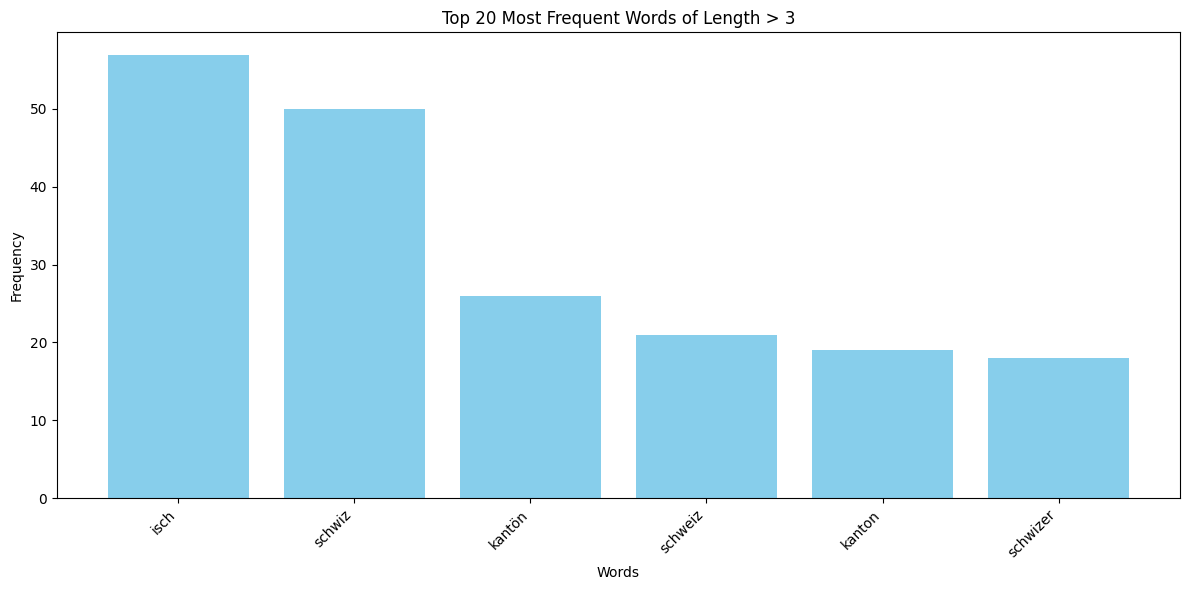

Displayed a bar chart of the top 20 most frequent words.


In [24]:

# Prepare data for plotting
words = [word for word, count in top_n_words if len(word) > 3]
counts = [count for word, count in top_n_words if len(word) > 3]

# Create the bar chart
plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='skyblue')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title(f'Top {N} Most Frequent Words of Length > 3')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Displayed a bar chart of the top {N} most frequent words.")

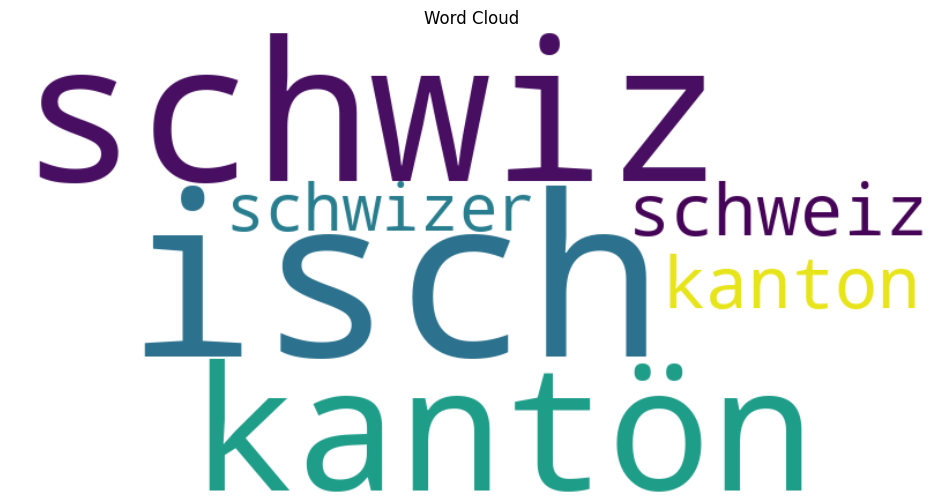

In [25]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(words))

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()

# Summarize Insights



The analysis of the Wikipedia article on "Schweiz" (Switzerland) reveals several key themes based on the most frequent words after preprocessing and stop word removal. The top 20 words largely revolve around geographical, political, and cultural aspects of Switzerland.

*   **Geographical and Administrative Structure:** Words like `kantön` (cantons), `schwiz` (Switzerland), `em` (likely a form of 'im' meaning 'in' or a pronoun 'them'), `dr` (the), `de` (the), `vo` (of), `uf` (on/upon) indicate a strong focus on the country's unique federal structure and physical landscape.
*   **Identity and Belonging:** The consistent appearance of `schwiz` and `schwizer` (Swiss) directly points to the article's core subject and national identity.
*   **High-Frequency Common Words:** Even after removing German stopwords, some very common words like `d` (the), `isch` (is), `het` (has), `i` (in), `e` (a), `au` (also), `si` (they/are) remain prominent. These are often structural elements of the German language that are difficult to fully filter without potentially losing context.

Overall, the most frequent non-stopwords suggest that the article provides a foundational overview of Switzerland, emphasizing its administrative divisions, geographical characteristics, and national identity. The presence of words like 'kantön' is particularly informative, immediately pointing to the decentralized nature of Swiss governance.